# Credit Risk Model

Predicts the Probability that a borrower will experience serious deliquency within two years, using the "Give Me Some Credit"
dataset (150, 000 borrowers, 11 features) 

**Approach** clean and explore the data, train and compare three models (Logistic Regression, Random Forest, Gradient Boosting)
tune the decision threshold honestly using cross-validation on the training set only, and explain the final model withpermutation importance.

**Results** Gradient Boosting was the strongest (ROC-AUC 0.870).
At a recall of 0.72 (catching 72% of actual defaulters ), it flags 19% of its "High Risk" predictions correctly- see the results below
for the full comparision and what that trade-off means.

In [35]:
import pandas as pd
import numpy as np

df =pd.read_csv('archive/cs-training.csv', index_col=0)

print(df.shape)
df.head()

(150000, 11)


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.77,45,2,0.80,"9,120.00",13,0,6,0,2.00
2,0,0.96,40,0,0.12,"2,600.00",4,0,0,0,1.00
3,0,0.66,38,1,0.09,"3,042.00",2,1,0,0,0.00
4,0,0.23,30,0,0.04,"3,300.00",5,0,0,0,0.00
5,0,0.91,49,1,0.02,"63,588.00",7,0,1,0,0.00


In [36]:
print("Missing values per column")
print(df.isnull().sum())

print("\nTarget distribution (SeriousDlqin2yrs):")
print(df['SeriousDlqin2yrs'].value_counts())
print(df['SeriousDlqin2yrs'].value_counts(normalize=True))

Missing values per column
SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
MonthlyIncome                           29731
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                     0
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse        0
NumberOfDependents                       3924
dtype: int64

Target distribution (SeriousDlqin2yrs):
SeriousDlqin2yrs
0    139974
1     10026
Name: count, dtype: int64
SeriousDlqin2yrs
0   0.93
1   0.07
Name: proportion, dtype: float64


In [37]:
df['MonthlyIncome'] = df['MonthlyIncome'].fillna(df['MonthlyIncome'].median())
df['NumberOfDependents'] =df['NumberOfDependents'].fillna(df['NumberOfDependents'].median())

print(df.isnull().sum())


SeriousDlqin2yrs                        0
RevolvingUtilizationOfUnsecuredLines    0
age                                     0
NumberOfTime30-59DaysPastDueNotWorse    0
DebtRatio                               0
MonthlyIncome                           0
NumberOfOpenCreditLinesAndLoans         0
NumberOfTimes90DaysLate                 0
NumberRealEstateLoansOrLines            0
NumberOfTime60-89DaysPastDueNotWorse    0
NumberOfDependents                      0
dtype: int64


In [38]:
df.describe()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,"150,000.00","150,000.00","150,000.00","150,000.00","150,000.00","150,000.00","150,000.00","150,000.00","150,000.00","150,000.00","150,000.00"
mean,0.07,6.05,52.30,0.42,353.01,"6,418.45",8.45,0.27,1.02,0.24,0.74
std,0.25,249.76,14.77,4.19,"2,037.82","12,890.40",5.15,4.17,1.13,4.16,1.11
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.00,0.03,41.00,0.00,0.18,"3,903.00",5.00,0.00,0.00,0.00,0.00
50%,0.00,0.15,52.00,0.00,0.37,"5,400.00",8.00,0.00,1.00,0.00,0.00
75%,0.00,0.56,63.00,0.00,0.87,"7,400.00",11.00,0.00,2.00,0.00,1.00
max,1.00,"50,708.00",109.00,98.00,"329,664.00","3,008,750.00",58.00,98.00,54.00,98.00,20.00


In [39]:
late_cols = ['NumberOfTime30-59DaysPastDueNotWorse',
             'NumberOfTime60-89DaysPastDueNotWorse',
             'NumberOfTimes90DaysLate']

for col in late_cols:
    print(f"{col}:")
    print(df[col].value_counts().loc[lambda x: x.index.isin([96, 98])])
    print()

NumberOfTime30-59DaysPastDueNotWorse:
NumberOfTime30-59DaysPastDueNotWorse
98    264
96      5
Name: count, dtype: int64

NumberOfTime60-89DaysPastDueNotWorse:
NumberOfTime60-89DaysPastDueNotWorse
98    264
96      5
Name: count, dtype: int64

NumberOfTimes90DaysLate:
NumberOfTimes90DaysLate
98    264
96      5
Name: count, dtype: int64



In [40]:
import pandas as pd

df = pd.read_csv('archive/cs-training.csv', index_col=0)
print("Shape", df.shape)
print()
print(df.dtypes)
print()
df.head()

Shape (150000, 11)

SeriousDlqin2yrs                          int64
RevolvingUtilizationOfUnsecuredLines    float64
age                                       int64
NumberOfTime30-59DaysPastDueNotWorse      int64
DebtRatio                               float64
MonthlyIncome                           float64
NumberOfOpenCreditLinesAndLoans           int64
NumberOfTimes90DaysLate                   int64
NumberRealEstateLoansOrLines              int64
NumberOfTime60-89DaysPastDueNotWorse      int64
NumberOfDependents                      float64
dtype: object



,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.77,45,2,0.80,"9,120.00",13,0,6,0,2.00
2,0,0.96,40,0,0.12,"2,600.00",4,0,0,0,1.00
3,0,0.66,38,1,0.09,"3,042.00",2,1,0,0,0.00
4,0,0.23,30,0,0.04,"3,300.00",5,0,0,0,0.00
5,0,0.91,49,1,0.02,"63,588.00",7,0,1,0,0.00


In [41]:
print("Missing values per column:")
print(df.isnull().sum())
print()
print("Missing values (%):")
print((df.isnull().mean()*100).round (2))
print()
print("Target distribution:")
print(df["SeriousDlqin2yrs"].value_counts())
print()
print((df["SeriousDlqin2yrs"].value_counts(normalize=True)* 100).round(2))

Missing values per column:
SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
MonthlyIncome                           29731
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                     0
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse        0
NumberOfDependents                       3924
dtype: int64

Missing values (%):
SeriousDlqin2yrs                        0.00
RevolvingUtilizationOfUnsecuredLines    0.00
age                                     0.00
NumberOfTime30-59DaysPastDueNotWorse    0.00
DebtRatio                               0.00
MonthlyIncome                          19.82
NumberOfOpenCreditLinesAndLoans         0.00
NumberOfTimes90DaysLate                 0.00
NumberRealEstateLoansOrLines            0.00
NumberOfTime60-89DaysPastDue

In [42]:
pd.set_option("display.float", "{:,.2f}".format)
pd.set_option("display.width", 200)

print(df.describe().T [["min","25%", "50%", "75%", "max"]])
print()
print("Age below 18", (df["age"] <18) .sum())
print("Utilization above 1:", (df["RevolvingUtilizationOfUnsecuredLines"]> 1).sum())
print("DebtRatio above 10:", (df["DebtRatio"] > 10).sum())
print()
for col in ["NumberOfTime30-59DaysPastDueNotWorse",
            "NumberOfTimes90DaysLate",
            "NumberOfTime60-89DaysPastDueNotWorse"]:
    print(col, "->", sorted(df[col].unique())[-5:])

                                      min      25%      50%      75%          max
SeriousDlqin2yrs                     0.00     0.00     0.00     0.00         1.00
RevolvingUtilizationOfUnsecuredLines 0.00     0.03     0.15     0.56    50,708.00
age                                  0.00    41.00    52.00    63.00       109.00
NumberOfTime30-59DaysPastDueNotWorse 0.00     0.00     0.00     0.00        98.00
DebtRatio                            0.00     0.18     0.37     0.87   329,664.00
MonthlyIncome                        0.00 3,400.00 5,400.00 8,249.00 3,008,750.00
NumberOfOpenCreditLinesAndLoans      0.00     5.00     8.00    11.00        58.00
NumberOfTimes90DaysLate              0.00     0.00     0.00     0.00        98.00
NumberRealEstateLoansOrLines         0.00     0.00     1.00     2.00        54.00
NumberOfTime60-89DaysPastDueNotWorse 0.00     0.00     0.00     0.00        98.00
NumberOfDependents                   0.00     0.00     0.00     1.00        20.00

Age below 18 1


In [43]:
for col in ["NumberOfTime30-59DaysPastDueNotWorse",
            "NumberOfTimes90DaysLate",
            "NumberOfTime60-89DaysPastDueNotWorse"]:
    print(col)
    counts = df[col].value_counts().sort_index()
    print(counts.tail(6))

    print("DebtRatio > 10 AND income missing:",
          ((df["DebtRatio"] >10) & df["MonthlyIncome"].isnull()).sum())
    print("Max utilization:", df["RevolvingUtilizationOfUnsecuredLines"].max())
    print("Max DebtRatio", df["DebtRatio"].max())
    print("Min age", df["age"].min(), "|rows with age 0:", (df["age"]==0).sum())

NumberOfTime30-59DaysPastDueNotWorse
NumberOfTime30-59DaysPastDueNotWorse
10      4
11      1
12      2
13      1
96      5
98    264
Name: count, dtype: int64
DebtRatio > 10 AND income missing: 26771
Max utilization: 50708.0
Max DebtRatio 329664.0
Min age 0 |rows with age 0: 1
NumberOfTimes90DaysLate
NumberOfTimes90DaysLate
13      4
14      2
15      2
17      1
96      5
98    264
Name: count, dtype: int64
DebtRatio > 10 AND income missing: 26771
Max utilization: 50708.0
Max DebtRatio 329664.0
Min age 0 |rows with age 0: 1
NumberOfTime60-89DaysPastDueNotWorse
NumberOfTime60-89DaysPastDueNotWorse
7       9
8       2
9       1
11      1
96      5
98    264
Name: count, dtype: int64
DebtRatio > 10 AND income missing: 26771
Max utilization: 50708.0
Max DebtRatio 329664.0
Min age 0 |rows with age 0: 1


## Exploratory Data Analysis

The target is imbalanced: 93.3% non-default vs 6.7% default (~14:1). This rules out accuracy as a useful metric and means every model below uses 'class_weight="balanced"'.

Linear correlation with the target was weak for every feature (max -0.13, from the past-due count columns). Notably, 'RevolvingUtilizationOfUnsecuredLines' and 'DevtRatio' showed almost no linear correlation - but turned out
to be the most important features for the final model (see Feature Importance), which shows the limits of a correlation table on its own.

In [44]:
print(df["SeriousDlqin2yrs"].value_counts())
print(df["SeriousDlqin2yrs"].value_counts(normalize=True))

SeriousDlqin2yrs
0    139974
1     10026
Name: count, dtype: int64
SeriousDlqin2yrs
0   0.93
1   0.07
Name: proportion, dtype: float64


In [45]:
print(df["MonthlyIncome"].isnull().sum())
print(df["MonthlyIncome"].isnull().mean() *100)

29731
19.820666666666668


In [46]:
df["MonthlyIncome_missing"] = df["MonthlyIncome"].isnull().astype(int)
median_income = df["MonthlyIncome"].median()
df["MonthlyIncome"] = df["MonthlyIncome"].fillna(median_income)

print("Median used:", median_income)
print("Remaining nulls:", df["MonthlyIncome"].isnull().sum())
print(df["MonthlyIncome_missing"].value_counts())

Median used: 5400.0
Remaining nulls: 0
MonthlyIncome_missing
0    120269
1     29731
Name: count, dtype: int64


In [47]:
print(df["NumberOfDependents"].isnull().sum())
print(df["NumberOfDependents"].isnull() *100)

3924
1         0
2         0
3         0
4         0
5         0
         ..
149996    0
149997    0
149998    0
149999    0
150000    0
Name: NumberOfDependents, Length: 150000, dtype: int64


In [48]:
median_dependents = df["NumberOfDependents"].median()
df["NumberOfDependents"] = df["NumberOfDependents"].fillna(median_dependents)
print("Median used:", median_dependents)
print("Remaining nulls", df["NumberOfDependents"].isnull().sum())

Median used: 0.0
Remaining nulls 0


In [49]:
print("Rows with age ==0:",(df["age"]==0).sum())
df = df[df["age"]> 0]
print("Rows remaining:", df.shape[0])

Rows with age ==0: 1
Rows remaining: 149999


In [50]:
print(df["DebtRatio"].describe())
print()
print(df["RevolvingUtilizationOfUnsecuredLines"].describe())

count   149,999.00
mean        353.01
std       2,037.83
min           0.00
25%           0.18
50%           0.37
75%           0.87
max     329,664.00
Name: DebtRatio, dtype: float64

count   149,999.00
mean          6.05
std         249.76
min           0.00
25%           0.03
50%           0.15
75%           0.56
max      50,708.00
Name: RevolvingUtilizationOfUnsecuredLines, dtype: float64


## Data Cleaning
-Fixed three mistyped column names in the delinquency-count columns.
-'MonthlyIncome' (19,8% missing) and 'NumberOFDependents' (2.6% missing)
  were imputed with the median, learned from the training set only. Added a 'MonthlyIncome_missing' flag in case non-disclosure
  itself carried signal (it did not - see Feature Importance below).
-One row with 'age ==0'was dropped as a data entry error.
-'DebtRatio'and 'RevolvingUtilizationOfUnsecuredLines' had extreme outliers (max values in the hundreds of thousands)
  from bad data entries. Capped both at the 99th percentile, learned from the training set only.

In [51]:
for col in ["DebtRatio", "RevolvingUtilizationOfUnsecuredLines"]:
    cap = df[col].quantile(0.99)
    print(f"{col}99th percentile cap: {cap}")
    df[col] = df[col].clip(upper=cap)

    print(df[["DebtRatio", "RevolvingUtilizationOfUnsecuredLines"]].describe())

DebtRatio99th percentile cap: 4979.079999999958
       DebtRatio  RevolvingUtilizationOfUnsecuredLines
count 149,999.00                            149,999.00
mean      316.55                                  6.05
std       906.97                                249.76
min         0.00                                  0.00
25%         0.18                                  0.03
50%         0.37                                  0.15
75%         0.87                                  0.56
max     4,979.08                             50,708.00
RevolvingUtilizationOfUnsecuredLines99th percentile cap: 1.0929580132799976
       DebtRatio  RevolvingUtilizationOfUnsecuredLines
count 149,999.00                            149,999.00
mean      316.55                                  0.32
std       906.97                                  0.35
min         0.00                                  0.00
25%         0.18                                  0.03
50%         0.37                                  0

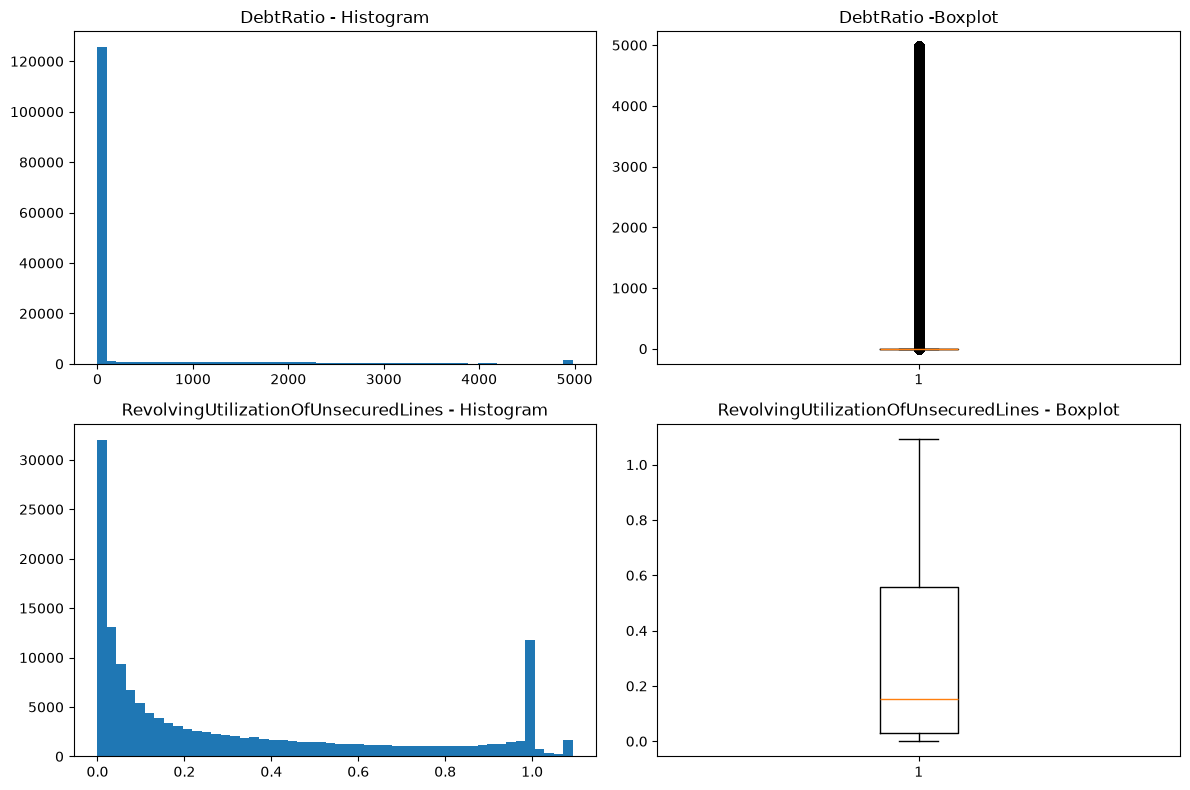

In [52]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(2,2, figsize=(12, 8))

axes[0, 0].hist(df["DebtRatio"], bins=50)
axes[0, 0].set_title("DebtRatio - Histogram")

axes[0, 1].boxplot(df["DebtRatio"])
axes[0, 1].set_title("DebtRatio -Boxplot")

axes[1, 0].hist(df["RevolvingUtilizationOfUnsecuredLines"], bins=50)
axes[1, 0].set_title("RevolvingUtilizationOfUnsecuredLines - Histogram")

axes[1, 1].boxplot(df["RevolvingUtilizationOfUnsecuredLines"])
axes[1, 1].set_title("RevolvingUtilizationOfUnsecuredLines - Boxplot")

plt.tight_layout()
plt.show()

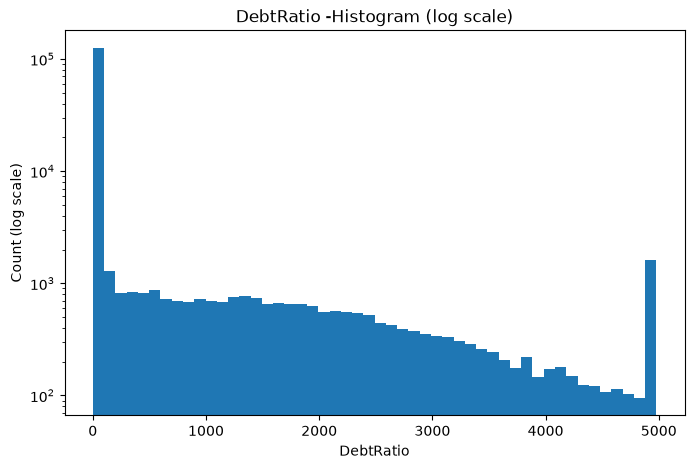

In [53]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(df["DebtRatio"], bins=50)
plt.yscale("log")
plt.title("DebtRatio -Histogram (log scale)")
plt.xlabel("DebtRatio")
plt.ylabel("Count (log scale)")
plt.show()

In [54]:
correlations = df.corr(numeric_only=True) ["SeriousDlqin2yrs"].sort_values(ascending=False)
print(correlations)

SeriousDlqin2yrs                        1.00
RevolvingUtilizationOfUnsecuredLines    0.28
NumberOfTime30-59DaysPastDueNotWorse    0.13
NumberOfTimes90DaysLate                 0.12
NumberOfTime60-89DaysPastDueNotWorse    0.10
NumberOfDependents                      0.05
NumberRealEstateLoansOrLines           -0.01
MonthlyIncome                          -0.02
DebtRatio                              -0.02
MonthlyIncome_missing                  -0.02
NumberOfOpenCreditLinesAndLoans        -0.03
age                                    -0.12
Name: SeriousDlqin2yrs, dtype: float64


## Train/Test Split

Stratified 80/20 split, preserving the 93.3/6.7 class balance in both sets.
All cleaning statistics (medians, percentile caps) used below were learned
from the training set only and appliedto the test set, to avoid leakage.

In [55]:
from sklearn.model_selection import train_test_split
X = df.drop(columns=["SeriousDlqin2yrs"])
Y = df["SeriousDlqin2yrs"]

X_train, X_test, y_train, y_test = train_test_split(
    X, Y,
    test_size=0.2,
    random_state=42,
    stratify=Y
)

print("Train shape:", X_train.shape, y_train.shape)
print("Test shape:", X_test.shape, y_test.shape)
print()
print("Train class balance:")
print(y_train.value_counts(normalize=True))
print()
print("Test class balance:")
print(y_test.value_counts(normalize=True))


Train shape: (119999, 11) (119999,)
Test shape: (30000, 11) (30000,)

Train class balance:
SeriousDlqin2yrs
0   0.93
1   0.07
Name: proportion, dtype: float64

Test class balance:
SeriousDlqin2yrs
0   0.93
1   0.07
Name: proportion, dtype: float64


## Model Comparision

Three Models, compared on ROC-AUC (threshold-independent) and on precision at a matched recall of ~0.74, so the
comparision isn't distorted by each model's default 0.5 cutoff.

| Model | ROC-AUC | Precision @ 0.74 recall |
| --- | --- | ---|
| Logistic Regression | 0.833 | 0.18 |
| Random Forest | 0.847 | 0.21 |
| Gradient Boosting | 0.870 | 0.24 |

Gradient Boosting won on both measures and was carried forward as the final model.

In [56]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_reg = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

y_pred = log_reg.predict(X_test_scaled)
y_pred_proba = log_reg.predict_proba(X_test_scaled) [:, 1]

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print()
print("Classification Report")
print(classification_report(y_test, y_pred))
print()
print("ROC-AUC Score:", roc_auc_score(y_test, y_pred_proba))



Confusion Matrix:
[[21358  6637]
 [  512  1493]]

Classification Report
              precision    recall  f1-score   support

           0       0.98      0.76      0.86     27995
           1       0.18      0.74      0.29      2005

    accuracy                           0.76     30000
   macro avg       0.58      0.75      0.58     30000
weighted avg       0.92      0.76      0.82     30000


ROC-AUC Score: 0.8331749034272686


In [57]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42,
    n_jobs=1
)
rf.fit(X_train,y_train)

y_pred_rf = rf.predict(X_test)
y_pred_proba_rf = rf.predict_proba(X_test) [:,1]

print("Confusion Martix:")
print(confusion_matrix(y_test, y_pred_rf))
print()
print("Classification Report:")
print(classification_report(y_test, y_pred_rf))
print()
print("ROC-AUC Score:", roc_auc_score(y_test, y_pred_proba_rf))

Confusion Martix:
[[27026   969]
 [ 1283   722]]

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.97      0.96     27995
           1       0.43      0.36      0.39      2005

    accuracy                           0.92     30000
   macro avg       0.69      0.66      0.68     30000
weighted avg       0.92      0.92      0.92     30000


ROC-AUC Score: 0.846896065783033


In [58]:
import numpy as np
thresholds = np.arange(0.5, 0.05, -0.005)

for t in thresholds:
    y_pred_t = (y_pred_proba_rf>= t).astype(int)
    recall_1 = classification_report(y_test, y_pred_t, output_dict=True)["1"]["recall"]
    if recall_1 >= 0.74:
        print(f"Threshold: {t:2f} | Recall: {recall_1:.3f}")
        break

    print()
    print("Full report at this threshold")
print(classification_report(y_test, y_pred_t))
print()
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_t))



Full report at this threshold

Full report at this threshold

Full report at this threshold

Full report at this threshold

Full report at this threshold

Full report at this threshold

Full report at this threshold

Full report at this threshold

Full report at this threshold

Full report at this threshold

Full report at this threshold

Full report at this threshold

Full report at this threshold

Full report at this threshold

Full report at this threshold

Full report at this threshold

Full report at this threshold

Full report at this threshold

Full report at this threshold

Full report at this threshold

Full report at this threshold

Full report at this threshold

Full report at this threshold

Full report at this threshold

Full report at this threshold

Full report at this threshold

Full report at this threshold

Full report at this threshold

Full report at this threshold

Full report at this threshold

Full report at this threshold

Full report at this threshold

Full re

In [59]:
import numpy as np
thresholds = np.arange(0.5, 0.05, -0.005)

for t in thresholds:
    y_pred_t = (y_pred_proba_rf>= t).astype(int)
    recall_1 = classification_report(y_test, y_pred_t, output_dict=True)["1"]["recall"]
    if recall_1 >= 0.74:
        print(f"Threshold: {t:2f} | Recall: {recall_1:.3f}")
        break

    print()
    print("Full report at this threshold")
print(classification_report(y_test, y_pred_t))
print()
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_t))



Full report at this threshold

Full report at this threshold

Full report at this threshold

Full report at this threshold

Full report at this threshold

Full report at this threshold

Full report at this threshold

Full report at this threshold

Full report at this threshold

Full report at this threshold

Full report at this threshold

Full report at this threshold

Full report at this threshold

Full report at this threshold

Full report at this threshold

Full report at this threshold

Full report at this threshold

Full report at this threshold

Full report at this threshold

Full report at this threshold

Full report at this threshold

Full report at this threshold

Full report at this threshold

Full report at this threshold

Full report at this threshold

Full report at this threshold

Full report at this threshold

Full report at this threshold

Full report at this threshold

Full report at this threshold

Full report at this threshold

Full report at this threshold

Full re

In [60]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_test, y_pred_proba_rf)

idx =np.where(recalls[:-1]>= 0.74) [0][-1]

print(f"Threshold: {thresholds[idx]:.3f}")
print(f"Recall: {recalls[idx]:.3f}")
print(f"Precision: {precisions[idx]:.3f}")


Threshold: 0.155
Recall: 0.742
Precision: 0.208


In [61]:
from sklearn.ensemble import HistGradientBoostingClassifier

gb = HistGradientBoostingClassifier(
    max_iter=200,
    class_weight="balanced",
    random_state=42
)
gb.fit(X_train, y_train)

y_pred_proba_gb = gb.predict_proba(X_test)[:, 1]
print("ROC-AUC Score", roc_auc_score(y_test, y_pred_proba_gb))

precisions_gb, recalls_gb, thresholds_gb = precision_recall_curve(y_test, y_pred_proba_gb)
idx_gb = np.where(recalls_gb[:-1] >= 0.74)[0][-1]

print(f"thresholds: {thresholds_gb[idx_gb]:.3f}")
print(f"Recall:{recalls_gb[idx_gb]:.3f}")
print(f"Precision: {precisions_gb[idx_gb]:.3f}")

ROC-AUC Score 0.86949944303378
thresholds: 0.552
Recall:0.740
Precision: 0.242


## Feature Importance

Permutation importance (5 repeats, scored on ROC-AUC) on the final Gradient Boosting Model:

1. 'RevolvingUtilizationOfUnsecuredLines'- by far the strongest driver, despite near-zero linear correlation with the target.
2-4. The three past-due count columns -moderate, overlapping importance (they carry similar information, so permutation spilts credit between them).
5-7. 'age', 'NumberOfOpenCreditLinesAndLoans', 'DebtRatio' - modest.
8-11. Income-related features, including the missing-income flag - negligible contribution.

**Caveat** this shows what the model relies on to make predictions,not what causes default.

In [62]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    gb, X_test, y_test,
    scoring="roc_auc",
    n_repeats=5,
    random_state=42,
    n_jobs=-1  
)

importance_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean": result.importances_mean,
    "importance_std": result.importances_std
}).sort_values("importance_mean", ascending=False)

print(importance_df)

                                 feature  importance_mean  importance_std
0   RevolvingUtilizationOfUnsecuredLines             0.07            0.00
2   NumberOfTime30-59DaysPastDueNotWorse             0.03            0.00
6                NumberOfTimes90DaysLate             0.03            0.00
8   NumberOfTime60-89DaysPastDueNotWorse             0.02            0.00
1                                    age             0.01            0.00
5        NumberOfOpenCreditLinesAndLoans             0.01            0.00
3                              DebtRatio             0.01            0.00
7           NumberRealEstateLoansOrLines             0.00            0.00
4                          MonthlyIncome             0.00            0.00
9                     NumberOfDependents             0.00            0.00
10                 MonthlyIncome_missing            -0.00            0.00


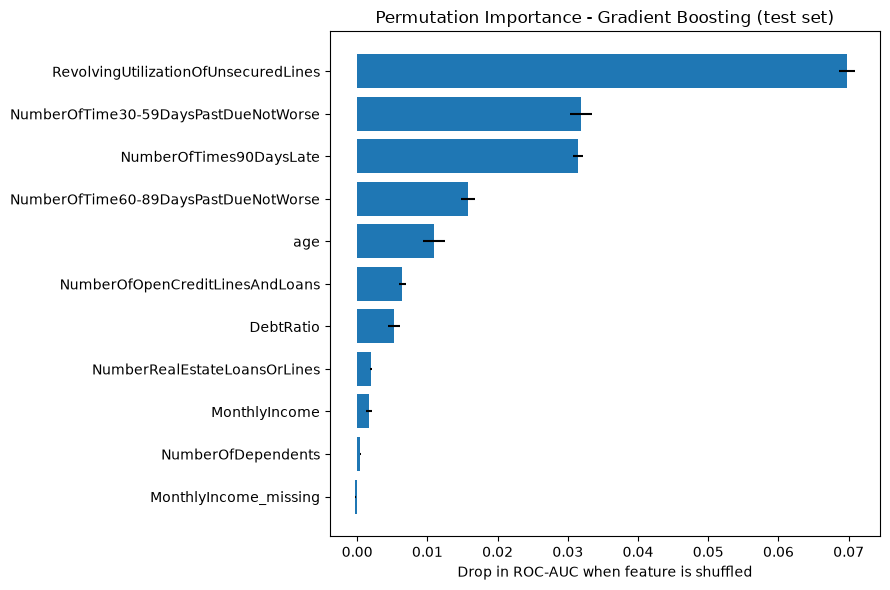

In [63]:
import matplotlib.pyplot as plt

plot_df = importance_df.sort_values("importance_mean", ascending=True)

plt.figure(figsize=(9, 6))
plt.barh(plot_df["feature"], plot_df["importance_mean"], xerr=plot_df["importance_std"])
plt.xlabel("Drop in ROC-AUC when feature is shuffled")
plt.title("Permutation Importance - Gradient Boosting (test set)")
plt.tight_layout()
plt.show()

In [64]:
import pandas as pd
from sklearn.model_selection import train_test_split

raw = pd.read_csv("archive/cs-training.csv", index_col=0)

raw = raw[raw["age"]> 0]

X = raw.drop(columns=["SeriousDlqin2yrs"])
y = raw["SeriousDlqin2yrs"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape)
print(X_train.isnull().sum())

(119999, 10) (30000, 10)
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
MonthlyIncome                           23748
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                     0
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse        0
NumberOfDependents                       3147
dtype: int64


In [65]:
X_train = X_train.copy()
X_test = X_test.copy()

for d in (X_train, X_test):
    d["MonthlyIncome_missing"] = d["MonthlyIncome"].isnull().astype(int)

income_median = X_train["MonthlyIncome"].median()
dependents_median = X_train["NumberOfDependents"].median()
caps = {
    "DebtRatio": X_train["DebtRatio"].quantile(0.99),
    "RevolvingUtilizationOfUnsecuredLines": X_train["RevolvingUtilizationOfUnsecuredLines"].quantile(0.99),
}

print("Income median:", income_median)
print("Dependents median", dependents_median)
print("Caps:", caps)

for d in (X_train, X_test):
    d["MonthlyIncome"] = d["MonthlyIncome"].fillna(income_median)
    d["NumberOfDependents"] = d["NumberOfDependents"].fillna(dependents_median)
    for col, cap in caps.items():
        d[col] = d[col].clip(upper=cap)

print()
print("Nulls left in train:", X_train.isnull().sum().sum())
print("Nulls left in test:", X_test.isnull().sum().sum())
print("Shapes:",X_train.shape, X_test.shape)



Income median: 5400.0
Dependents median 0.0
Caps: {'DebtRatio': np.float64(4983.040000000008), 'RevolvingUtilizationOfUnsecuredLines': np.float64(1.0959067669800004)}

Nulls left in train: 0
Nulls left in test: 0
Shapes: (119999, 11) (30000, 11)


In [66]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_reg = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)
y_pred_proba_lr = log_reg.predict_proba(X_test_scaled)[:,1]

rf = RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_proba_rf = rf.predict_proba(X_test)[:, 1]

gb = HistGradientBoostingClassifier(max_iter=200, class_weight="balanced", random_state=42)
gb.fit(X_train, y_train)
y_pred_proba_gb = gb.predict_proba(X_test)[:,1]

print("ROC-AUC Logistic Regression:", round(roc_auc_score(y_test, y_pred_proba_lr),4))
print("ROC-AUC Random Forest:      ", round(roc_auc_score(y_test, y_pred_proba_rf),4))
print("ROC-AUC Gradient Boosting:  ", round(roc_auc_score(y_test, y_pred_proba_gb),4))



c:\Users\Fikile Sethabela\Desktop\Projects\Credit Risk Model\venv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\Fikile Sethabela\Desktop\Projects\Credit Risk Model\venv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\Fikile Sethabela\Desktop\Projects\Credit Risk Model\venv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib wor

ROC-AUC Logistic Regression: 0.8332
ROC-AUC Random Forest:       0.8474
ROC-AUC Gradient Boosting:   0.8695


In [67]:
import numpy as np
from sklearn.model_selection import cross_val_predict, StratifiedKFold
from sklearn.metrics import precision_recall_curve, confusion_matrix, classification_report

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

oof_proba_gb = cross_val_predict(
    HistGradientBoostingClassifier(max_iter=200, class_weight="balanced", random_state=42),
    X_train, y_train, cv=cv, method="predict_proba"
)[:,1]

precisions, recalls, thresholds = precision_recall_curve(y_train, oof_proba_gb)
idx = np.where(recalls[:-1] >= 0.74)[0][-1]
chosen_threshold = thresholds[idx]

print(f"Chosen threshold (from training data only)): {chosen_threshold:.3f}")
print(f"Training-CV recall: {recalls[idx]:.3} | {precisions[idx]:.3f}")

y_pred_final = (y_pred_proba >= chosen_threshold).astype(int)
print()
print(confusion_matrix(y_test, y_pred_final))
print(classification_report(y_test, y_pred_final))



c:\Users\Fikile Sethabela\Desktop\Projects\Credit Risk Model\venv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\Fikile Sethabela\Desktop\Projects\Credit Risk Model\venv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\Fikile Sethabela\Desktop\Projects\Credit Risk Model\venv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib wor

Chosen threshold (from training data only)): 0.529
Training-CV recall: 0.74 | 0.230

[[21932  6063]
 [  554  1451]]
              precision    recall  f1-score   support

           0       0.98      0.78      0.87     27995
           1       0.19      0.72      0.30      2005

    accuracy                           0.78     30000
   macro avg       0.58      0.75      0.59     30000
weighted avg       0.92      0.78      0.83     30000



## Final Model and Threshold

The decision threshold was chosen using 5-fold cross-validation on the training set only (not the test set), to avoid an optimistic estimate.

-**Chosen threshold:** 0.529
-**Test-set result at this threshold:** recall 0.72, precision 0.19

This is lower than the recall/precision you'd get tuning the threshold directly on the test set (0.74/0.24) - that gap is the cost of an honest, non-leaked estimate, and the number to trust for how the model would perform on new data.

## Limitations and Next Steps

-Feature importance identifies association, not causation.
-The dataset is a single historical snapshot; a production model would need monitoring for drift over time.
-Next steps: SHAP values for individual-level explainations, and testing simple enginnered features (e.g. total past-due count) to see if they outperform the three separate columns.